In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_curve, roc_auc_score
import shap

# =====================================================================
# STEP 1: LOAD DATA AND REMOVE NULL VALUES
# =====================================================================
# Load the dataset using the semicolon delimiter
df = pd.read_csv('https://www.dropbox.com/scl/fi/l7la2q3aj9gz4z56oiuiu/bank-full.csv?rlkey=d5znbvl7k5hzju2vc5rtix4zh&st=2vyty6hh&dl=1', sep=';')

# Drop any actual missing/null rows if they exist
df = df.dropna()

print("Step 1 Completed: Data loaded successfully. Shape:", df.shape)

Step 1 Completed: Data loaded successfully. Shape: (45211, 17)


In [2]:
# =====================================================================
# STEP 2: PREPROCESSING & FEATURE ENCODING
# =====================================================================
# Create a fresh copy of the dataset to keep the original safe
processed_df = df.copy()

# List out every column that contains text data instead of numbers
categorical_columns = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

for col in categorical_columns:
    encoder = LabelEncoder()
    processed_df[col] = encoder.fit_transform(processed_df[col])

print("Step 2 Completed: All text features converted into numbers.")


Step 2 Completed: All text features converted into numbers.


In [3]:
# =====================================================================
# STEP 3: SPLITTING THE DATASET
# =====================================================================
X = processed_df.drop(columns=['y'])
y = processed_df['y']

# Split the dataset: 80% for training the models, 20% for testing them
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Step 3 Completed: Split data into {X_train.shape[0]} training and {X_test.shape[0]} testing rows.")


Step 3 Completed: Split data into 36168 training and 9043 testing rows.


In [4]:
# =====================================================================
# STEP 4: TRAINING THE CLASSIFICATION MODELS
# =====================================================================

# 1. Logistic Regression
print("Training Tuned Logistic Regression model...")
lr_model = LogisticRegression(max_iter=10000, class_weight='balanced', random_state=42)
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)
lr_probabilities = lr_model.predict_proba(X_test)[:, 1]


# 2. Random Forest (Tuned to prevent overfitting!)
print("Training Tuned Random Forest model...")
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=14, min_samples_split=5, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

print("Step 4 Completed: Tuned models trained successfully!")

Training Tuned Logistic Regression model...
Training Tuned Random Forest model...
Step 4 Completed: Tuned models trained successfully!



--- Model Results ---
Logistic Regression Score: 0.4987
Random Forest Score: 0.5947


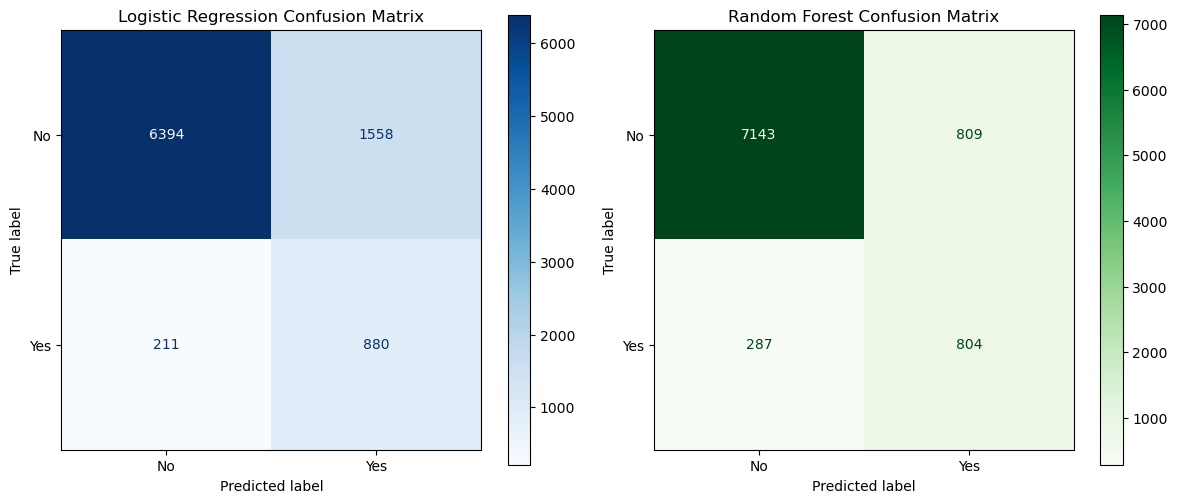

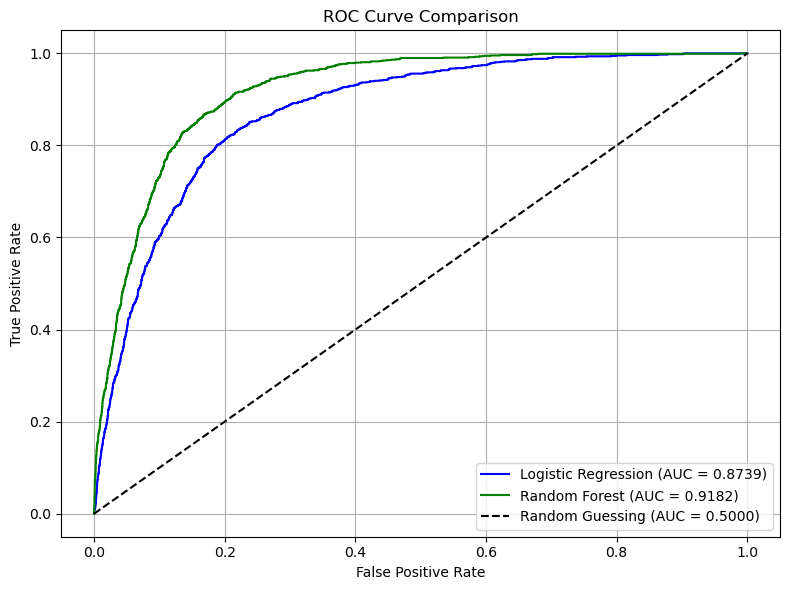

In [5]:
# =====================================================================
# STEP 5: EVALUATION AND VISUALIZATIONS
# =====================================================================

# --- A. Calculate and Print F1-Scores ---
lr_f1 = f1_score(y_test, lr_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print(f"\n--- Model Results ---")
print(f"Logistic Regression Score: {lr_f1:.4f}")
print(f"Random Forest Score: {rf_f1:.4f}")


# --- B. Create and Save Confusion Matrix Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, lr_predictions)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No', 'Yes'])
disp_lr.plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression Confusion Matrix')

# Plot Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_predictions)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No', 'Yes'])
disp_rf.plot(ax=axes[1], cmap='Greens')
axes[1].set_title('Random Forest Confusion Matrix')

plt.tight_layout()


# --- C. Create and Save ROC Curve Plot ---
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probabilities)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probabilities)

auc_lr = roc_auc_score(y_test, lr_probabilities)
auc_rf = roc_auc_score(y_test, rf_probabilities)

fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
ax_roc.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})', color='blue')
ax_roc.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})', color='green')
ax_roc.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.5000)')

ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve Comparison')
ax_roc.legend()
ax_roc.grid(True)

plt.tight_layout()


Calculating SHAP values for 5 model predictions...


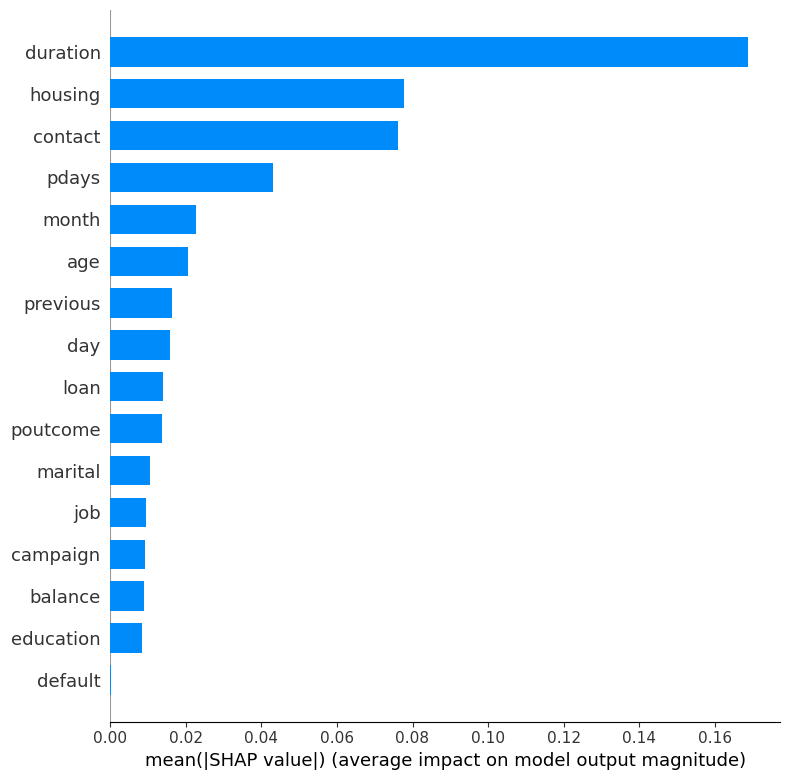

In [6]:
# =====================================================================
# STEP 6: MODEL INTERPRETABILITY (SHAP EXPLANATIONS)
# =====================================================================
print("\nCalculating SHAP values for 5 model predictions...")

# Pick out the first 5 records from our test set as requested
X_sample = X_test.head(5)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    shap_values_to_plot = shap_values[:, :, 1]
else:
    shap_values_to_plot = shap_values

# Create a chart showing feature importance for these 5 specific predictions
fig_shap, ax_shap = plt.subplots(figsize=(8, 5))

# Use our safely assigned matrix to plot
shap.summary_plot(shap_values_to_plot, X_sample, plot_type="bar", show=False)

plt.tight_layout()